In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
claims = pd.read_csv('merged_data.csv', low_memory = False)
print(claims.shape)
print(claims.head())

(558211, 56)
      BeneID   ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0  BENE11001  CLM46614   2009-04-12  2009-04-18  PRV55912   
1  BENE11001  CLM66048   2009-08-31  2009-09-02  PRV55907   
2  BENE11001  CLM68358   2009-09-17  2009-09-20  PRV56046   
3  BENE11011  CLM38412   2009-02-14  2009-02-22  PRV52405   
4  BENE11014  CLM63689   2009-08-13  2009-08-30  PRV56614   

   InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                   26000          PHY390922                NaN   
1                    5000          PHY318495          PHY318495   
2                    5000          PHY372395                NaN   
3                    5000          PHY369659          PHY392961   
4                   10000          PHY379376          PHY398258   

  OtherPhysician AdmissionDt  ... ChronicCond_IschemicHeart  \
0            NaN  2009-04-12  ...                         1   
1            NaN  2009-08-31  ...                         1   
2      PHY324689  2009-09-17

In [4]:
# Remove duplicates
print("Before duplicates removal:", claims.shape)
claims = claims.drop_duplicates()
print("After duplicates removal:", claims.shape)

Before duplicates removal: (558211, 56)
After duplicates removal: (558211, 56)


In [7]:
# Fill numerical missing values with 0
numerical_cols = claims.select_dtypes(include=[np.number]).columns
claims[numerical_cols] = claims[numerical_cols].fillna(0)

# Fill categorical missing values with 'Unknown'
categorical_cols = claims.select_dtypes(include=['object', 'string']).columns
claims[categorical_cols] = claims[categorical_cols].fillna('Unknown')

# Verify no missing values remain
print(claims.isnull().sum().sum())

0


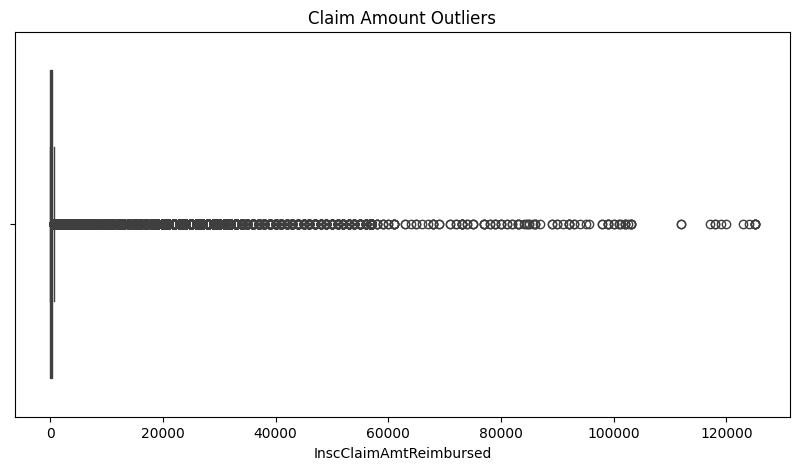

In [8]:
# Check outliers in claim amount
plt.figure(figsize=(10,5))
sns.boxplot(x=claims['InscClaimAmtReimbursed'])
plt.title('Claim Amount Outliers')
plt.show()

In [9]:
# Convert date columns to datetime
date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']

for col in date_cols:
    if col in claims.columns:
        claims[col] = pd.to_datetime(claims[col], errors='coerce')

print("Date columns converted successfully!")

Date columns converted successfully!


C:\Users\kmoha\AppData\Local\Temp\ipykernel_21168\2203129958.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  claims[col] = pd.to_datetime(claims[col], errors='coerce')


In [10]:
date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']

for col in date_cols:
    if col in claims.columns:
        claims[col] = pd.to_datetime(claims[col], format='%Y-%m-%d', errors='coerce')

print("Date columns converted successfully!")

Date columns converted successfully!


In [11]:
# Age of patient
claims['Age'] = 2024 - claims['DOB'].dt.year

# Claim duration in days
claims['ClaimDuration'] = (claims['ClaimEndDt'] - claims['ClaimStartDt']).dt.days

# Hospital stay duration
if 'AdmissionDt' in claims.columns and 'DischargeDt' in claims.columns:
    claims['HospitalStayDays'] = (claims['DischargeDt'] - claims['AdmissionDt']).dt.days

# Is patient deceased
claims['IsDeceased'] = claims['DOD'].notnull().astype(int)

print("New features created successfully!")
print(claims[['Age', 'ClaimDuration', 'HospitalStayDays', 'IsDeceased']].head())

New features created successfully!
   Age  ClaimDuration  HospitalStayDays  IsDeceased
0   81              6               6.0           0
1   81              2               2.0           0
2   81              3               3.0           0
3  110              8               8.0           0
4   86             17              17.0           0


In [12]:
# Convert Yes/No to 1/0
claims['PotentialFraud'] = claims['PotentialFraud'].map({'Yes': 1, 'No': 0})

print(claims['PotentialFraud'].value_counts())

PotentialFraud
0    345415
1    212796
Name: count, dtype: int64


In [13]:
# Drop columns not needed for model
drop_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt',
             'DischargeDt', 'DOB', 'DOD', 'BeneID', 'ClaimID']

claims = claims.drop(columns=[col for col in drop_cols if col in claims.columns])

print(claims.shape)
print(claims.columns)

(558211, 51)
Index(['Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician',
       'OperatingPhysician', 'OtherPhysician', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
       'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
       'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
       'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County',
       'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease',
       'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary',
       'ChronicCond_Depression', 'ChronicCond_Diabetes',
       'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis',
       'ChronicCond

In [15]:
# Convert categorical columns to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = claims.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    claims[col] = le.fit_transform(claims[col].astype(str))

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [16]:
print("Final Dataset Shape:", claims.shape)
print("Fraud Distribution:")
print(claims['PotentialFraud'].value_counts())
print(claims.head())

Final Dataset Shape: (558211, 51)
Fraud Distribution:
PotentialFraud
0    345415
1    212796
Name: count, dtype: int64
   Provider  InscClaimAmtReimbursed  AttendingPhysician  OperatingPhysician  \
0      3928                   26000               53275               35315   
1      3923                    5000                4951                2132   
2      4034                    5000               40843               35315   
3      1125                    5000               39020               23575   
4      4490                   10000               45475               25118   

   OtherPhysician  ClmAdmitDiagnosisCode  DeductibleAmtPaid  \
0           46457                   3022             1068.0   
1           46457                   2298             1068.0   
2            5201                    851             1068.0   
3           14717                   1602             1068.0   
4           46457                   2976             1068.0   

   DiagnosisGroupCode  ClmD

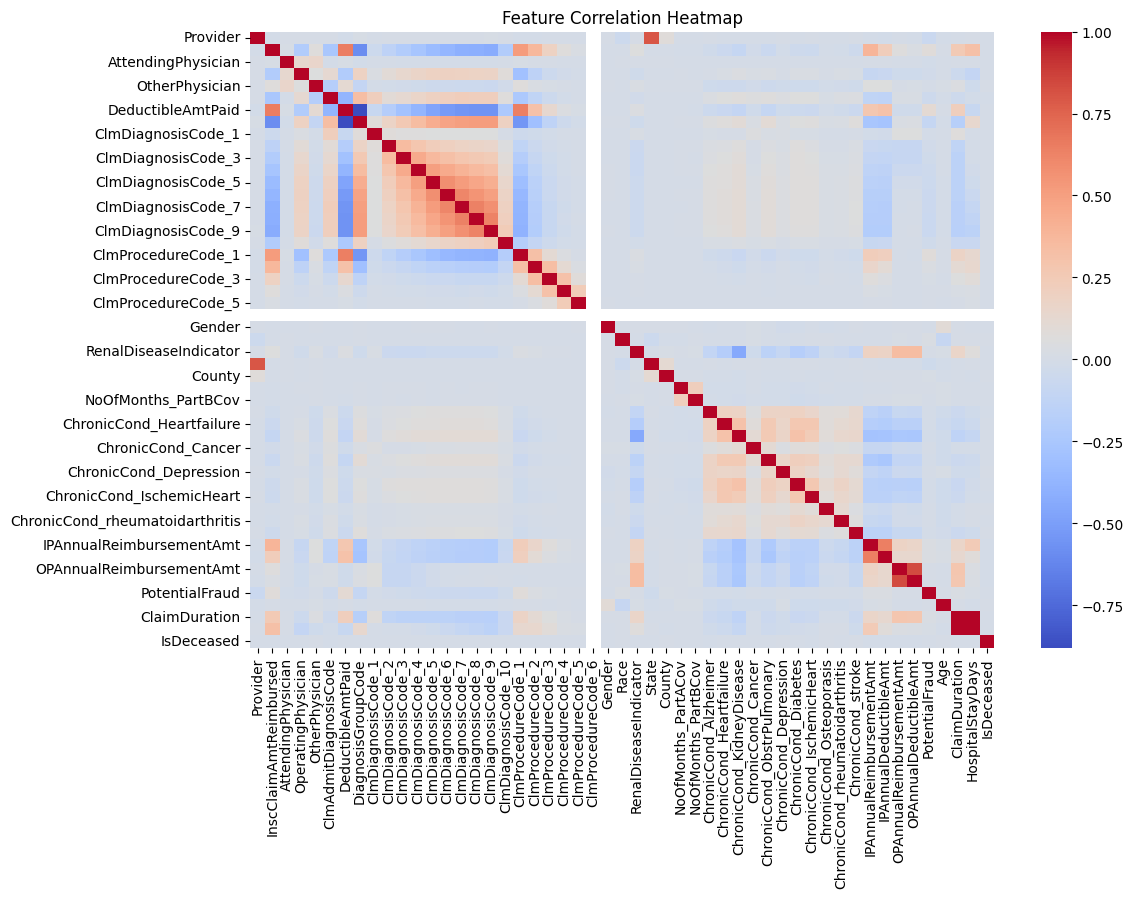

In [17]:
# Check correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(claims.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [18]:
claims.to_csv('cleaned_data.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [20]:
print(claims.isnull().sum())

Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                      0
OperatingPhysician                      0
OtherPhysician                          0
ClmAdmitDiagnosisCode                   0
DeductibleAmtPaid                       0
DiagnosisGroupCode                      0
ClmDiagnosisCode_1                      0
ClmDiagnosisCode_2                      0
ClmDiagnosisCode_3                      0
ClmDiagnosisCode_4                      0
ClmDiagnosisCode_5                      0
ClmDiagnosisCode_6                      0
ClmDiagnosisCode_7                      0
ClmDiagnosisCode_8                      0
ClmDiagnosisCode_9                      0
ClmDiagnosisCode_10                     0
ClmProcedureCode_1                      0
ClmProcedureCode_2                      0
ClmProcedureCode_3                      0
ClmProcedureCode_4                      0
ClmProcedureCode_5                      0
ClmProcedureCode_6                

In [21]:
fraud_percentage = (
    claims['PotentialFraud']
    .value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

PotentialFraud
0    61.878931
1    38.121069
Name: proportion, dtype: float64


In [22]:
claims.to_csv('cleaned_data.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
